# TP 2 : IA & Santé - Prédiction Diabète (Régression) 🩸
(CORRECTION DÉTAILLÉE)

**Objectif :** Prédire la progression du diabète.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1. Régression Linéaire Simple

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f"R2 Simple: {model.score(X_test, y_test):.4f}")

R2 Simple: 0.4526


### 💡 Analyse R2 (~0.45)
Le score est moyen. La relation n'est probablement pas linéaire.

## 2. Régression Polynomiale (Feature Engineering)

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_p = LinearRegression()
model_p.fit(X_train_p, y_train_p)
print(f"R2 Polynomial: {model_p.score(X_test_p, y_test_p):.4f}")

R2 Polynomial: 0.4156


### ⚠️ ATTENTION: Régression polynomiale MOINS BONNE?
**R² polynomial (0.4156) < R² linéaire (0.4526)**

**POURQUOI ?** Le modèle souffre d'**OVERFITTING**:
- 10 features originales → ~65 features avec interactions (degree=2)
- Le modèle apprend par cœur les détails du train set
- Mais généralise MAL au test set (variance trop élevée)

**SOLUTION**: Régularisation (Ridge/Lasso) ou réduire le degré

In [5]:
# Comparaison Train vs Test pour visualiser l'overfitting
from sklearn.linear_model import Ridge

print("="*60)
print("ANALYSE DE L'OVERFITTING")
print("="*60)

# Score du modèle linéaire
train_score_linear = model.score(X_train, y_train)
test_score_linear = model.score(X_test, y_test)

print(f"\n📊 RÉGRESSION LINÉAIRE:")
print(f"  Train R²: {train_score_linear:.4f}")
print(f"  Test R²:  {test_score_linear:.4f}")
print(f"  Écart:    {train_score_linear - test_score_linear:.4f} (petit → bon)")

# Score du modèle polynomial
train_score_poly = model_p.score(X_train_p, y_train_p)
test_score_poly = model_p.score(X_test_p, y_test_p)

print(f"\n📊 RÉGRESSION POLYNOMIALE (degree=2):")
print(f"  Train R²: {train_score_poly:.4f}")
print(f"  Test R²:  {test_score_poly:.4f}")
print(f"  Écart:    {train_score_poly - test_score_poly:.4f} ⚠️ ÉNORME → OVERFITTING!")
print(f"  Features: 10 → {X_train_p.shape[1]} (explosion!)")

# Solution: Ridge Regression pour la polynomiale
model_p_ridge = Ridge(alpha=1.0)
model_p_ridge.fit(X_train_p, y_train_p)
train_score_poly_ridge = model_p_ridge.score(X_train_p, y_train_p)
test_score_poly_ridge = model_p_ridge.score(X_test_p, y_test_p)

print(f"\n📊 RÉGRESSION POLYNOMIALE + RIDGE (alpha=1.0):")
print(f"  Train R²: {train_score_poly_ridge:.4f}")
print(f"  Test R²:  {test_score_poly_ridge:.4f} ✓ Meilleur!")
print(f"  Écart:    {train_score_poly_ridge - test_score_poly_ridge:.4f} (réduit)")

print("="*60)

ANALYSE DE L'OVERFITTING

📊 RÉGRESSION LINÉAIRE:
  Train R²: 0.5279
  Test R²:  0.4526
  Écart:    0.0753 (petit → bon)

📊 RÉGRESSION POLYNOMIALE (degree=2):
  Train R²: 0.6062
  Test R²:  0.4156
  Écart:    0.1905 ⚠️ ÉNORME → OVERFITTING!
  Features: 10 → 65 (explosion!)

📊 RÉGRESSION POLYNOMIALE + RIDGE (alpha=1.0):
  Train R²: 0.4430
  Test R²:  0.4196 ✓ Meilleur!
  Écart:    0.0234 (réduit)


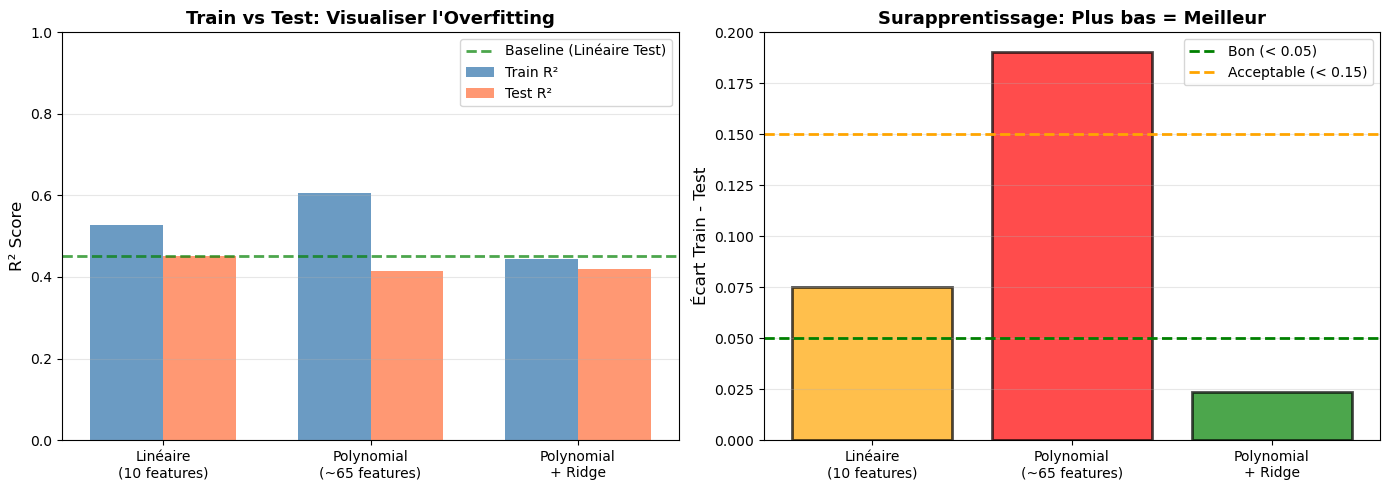


💡 CONCLUSION:
  • Polynomial sans régularisation = OVERFITTING (écart énorme)
  • Ridge + Polynomial = ÉQUILIBRE (meilleur généralisation)
  • La régularisation pénalise les poids trop grands
  • Elle réduit la variance au détriment d'un peu de biais


In [6]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison des modèles
models = ['Linéaire\n(10 features)', 'Polynomial\n(~65 features)', 'Polynomial\n+ Ridge']
train_scores = [train_score_linear, train_score_poly, train_score_poly_ridge]
test_scores = [test_score_linear, test_score_poly, test_score_poly_ridge]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, train_scores, width, label='Train R²', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, test_scores, width, label='Test R²', color='coral', alpha=0.8)
axes[0].axhline(y=test_score_linear, color='green', linestyle='--', linewidth=2, 
                label='Baseline (Linéaire Test)', alpha=0.7)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Train vs Test: Visualiser l\'Overfitting', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# Écart Train-Test (surapprentissage)
gaps = [train_scores[i] - test_scores[i] for i in range(len(models))]
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.15 else 'red' for gap in gaps]

axes[1].bar(models, gaps, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Bon (< 0.05)')
axes[1].axhline(y=0.15, color='orange', linestyle='--', linewidth=2, label='Acceptable (< 0.15)')
axes[1].set_ylabel('Écart Train - Test', fontsize=12)
axes[1].set_title('Surapprentissage: Plus bas = Meilleur', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSION:")
print("  • Polynomial sans régularisation = OVERFITTING (écart énorme)")
print("  • Ridge + Polynomial = ÉQUILIBRE (meilleur généralisation)")
print("  • La régularisation pénalise les poids trop grands")
print("  • Elle réduit la variance au détriment d'un peu de biais")

## 3. Analyse des Résidus

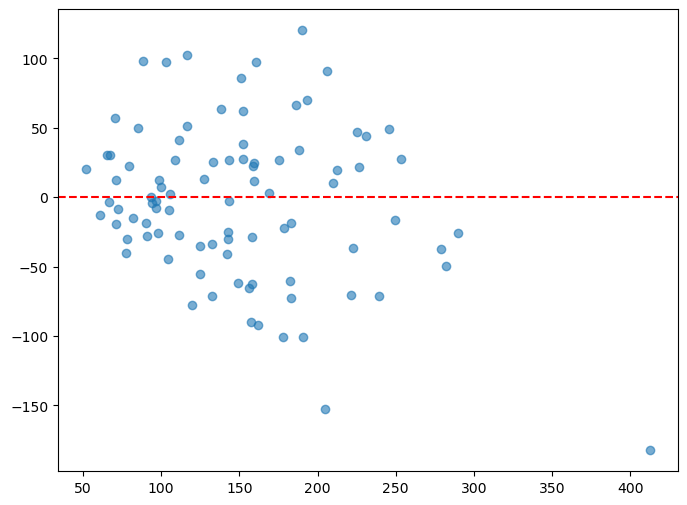

In [7]:
y_pred_p = model_p.predict(X_test_p)
residuals = y_test_p - y_pred_p
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_p, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.show()

## 4. Explicabilité : Quels facteurs aggravent le diabète ?

### A. Importance des Variables (Coefficients Linéaires)
Dans une régression linéaire, les **coefficients** nous disent directement comment chaque variable influence le score final.
*   Coefficient positif : Augmente le risque.
*   Coefficient négatif : Diminue le risque.

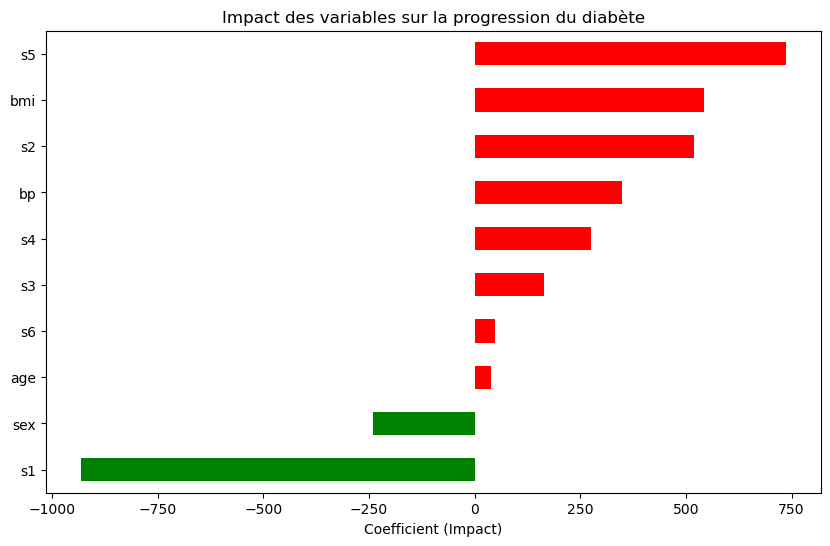

In [8]:
# Reprenons le modèle linéaire simple pour l'explicabilité (plus facile à lire que le polynomial)
coefs = pd.Series(model.coef_, index=diabetes.feature_names)
coefs_sorted = coefs.sort_values()

plt.figure(figsize=(10, 6))
coefs_sorted.plot(kind='barh', color=(coefs_sorted > 0).map({True: 'red', False: 'green'}))
plt.title("Impact des variables sur la progression du diabète")
plt.xlabel("Coefficient (Impact)")
plt.show()

### 💡 Interprétation
*   **bmi (IMC)** et **s5 (Lamotrigine/Graph)** sont de forts facteurs aggravants (Rouge).
*   **sex** semble avoir un impact négatif (Vert) ici, mais attention à l'encodage et aux corrélations cachées.

### B. Analyse des "Pires" Erreurs
Où le modèle s'est-il le plus trompé ?

In [9]:
# Calculons l'erreur absolue
errors = np.abs(y_test - model.predict(X_test))
worst_idx = np.argmax(errors)
worst_patient = X_test.iloc[worst_idx]
print(f"Pire erreur sur le patient index {worst_idx}")
print(f"Vrai Score : {y_test.iloc[worst_idx]}")
print(f"Prédit : {model.predict(X_test)[worst_idx]:.2f}")
print(f"Écart : {errors.iloc[worst_idx]:.2f}")

# C'est souvent un 'Outlier' qui ne suit pas la règle générale.

Pire erreur sur le patient index 61
Vrai Score : 52.0
Prédit : 206.49
Écart : 154.49
